# Dataset: Telco Customer Churn

**Project Overview**
This project predicts whether a customer will **churn** (ยกเลิกบริการ) using Telco Customer Churn dataset.  
Objective: Improve customer retention & identify high-risk customers.

**Business Objective**
- ระบุกลุ่มลูกค้ามีโอกาสยกเลิกบริการสูง  
- ส่งโปรโมชัน/สิทธิพิเศษเฉพาะกลุ่ม  
- ลดค่าใช้จ่ายจากการหาลูกค้าใหม่

**Dataset Summary**
- Rows: ~7,000  
- Target: `Churn`  
- Features: ลูกค้าสมัครบริการอะไร ใช้เน็ตแบบใด จ่ายเงินรายเดือนไม่เท่ากัน  
- Missing Data: พบเฉพาะใน `TotalCharges`

**Approach & Workflow**
1. Data Cleaning  
2. Exploratory Data Analysis  
3. Encode Categorical Variables  
4. Train/Test Split  
5. Train Model (Random Forest)  
6. Evaluate Performance  
7. Feature Interpretation  

**Skills Demonstrated**
- Python
- Data Cleaning  
- EDA & Visualization  
- Feature Engineering  
- Machine Learning (Random Forest)  
- Model Evaluation (Accuracy, F1-score)  
- Interpretation (Feature Importance)  
- Kaggle Notebook / GitHub Workflow  

**Import Libraries**

ใช้ pandas, numpy สำหรับจัดการข้อมูล, matplotlib/seaborn สำหรับ visualization, sklearn สำหรับ preprocessing, model, และ evaluation metrics

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

**Load Dataset**

โหลดไฟล์ Telco Customer Churn CSV และดูข้อมูลเบื้องต้น

In [8]:
import os
os.listdir('/kaggle/input/telco-customer-churn')

['WA_Fn-UseC_-Telco-Customer-Churn.csv']

In [9]:
data = pd.read_csv('/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Data Cleaning & Preprocessing**

* แปลง `TotalCharges` เป็นตัวเลขและเติมค่า missing
* Encode ข้อมูล categorical เป็นตัวเลขด้วย LabelEncoder เพื่อให้โมเดล ML ใช้งานได้

In [10]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'] = data['TotalCharges'].fillna(0)

cat_cols = data.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])

**Exploratory Data Analysis (EDA)**

* ดู distribution ของ target 'Churn'
* วิเคราะห์ correlation ของ features ด้วย heatmap

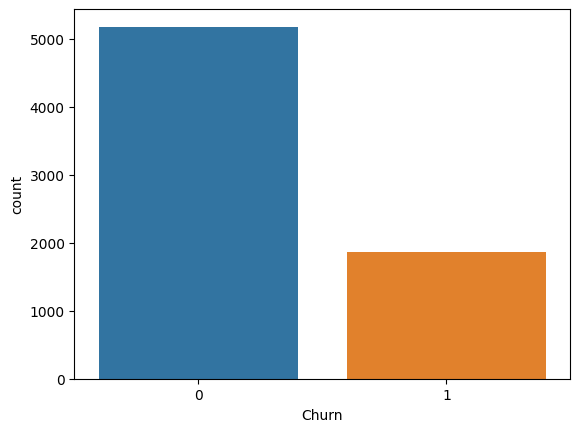

In [11]:
sns.countplot(x='Churn', data=data)
plt.show()

**Correlation heatmap**

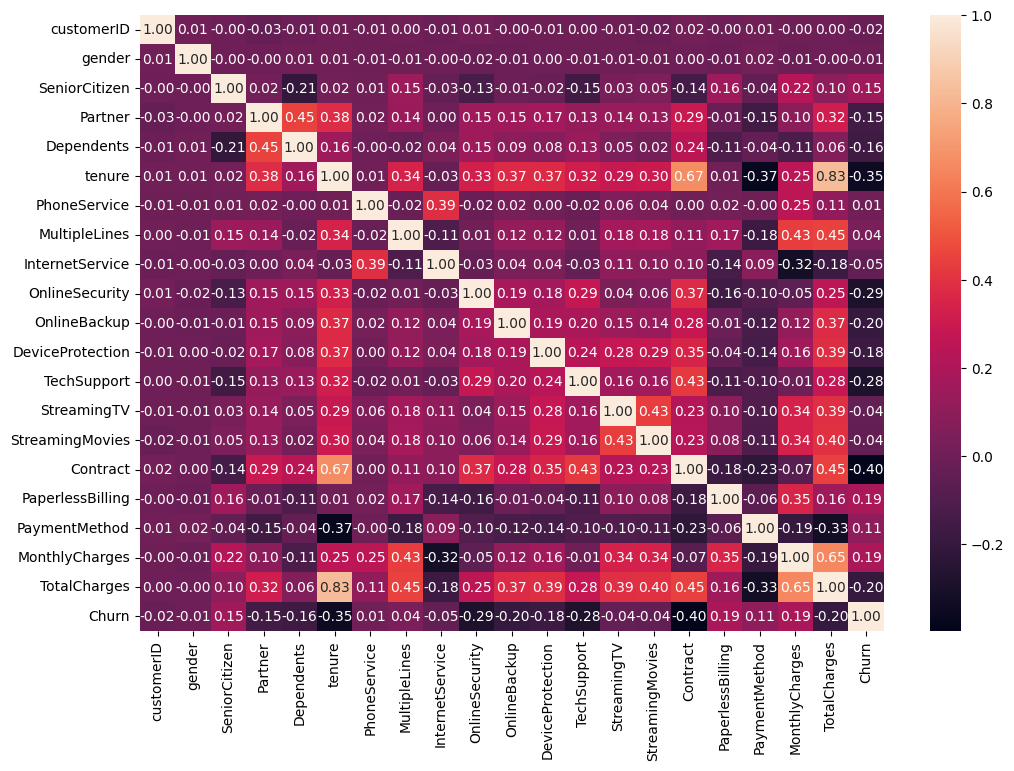

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True, fmt=".2f")
plt.show()

**Feature & Target**

`X` = all features  
`y` = target column `Churn`

In [13]:
X = data.drop('Churn', axis=1)
y = data['Churn']

**Train/Test Split**

แบ่งข้อมูลเป็น 80% train และ 20% test

In [14]:
X = data.drop('Churn', axis=1)
y = data['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Train Model (Random Forest)**

ใช้ RandomForestClassifier ฝึกโมเดลด้วย training set

In [15]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

**Evaluate Model Performance**

* วัด Accuracy และ F1 Score
* ดูรายละเอียดผลลัพธ์ด้วย Classification Report
* แสดง Confusion Matrix

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7998580553584103
F1 Score: 0.5688073394495413
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.50      0.57       373

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



**Confusion Matrix**

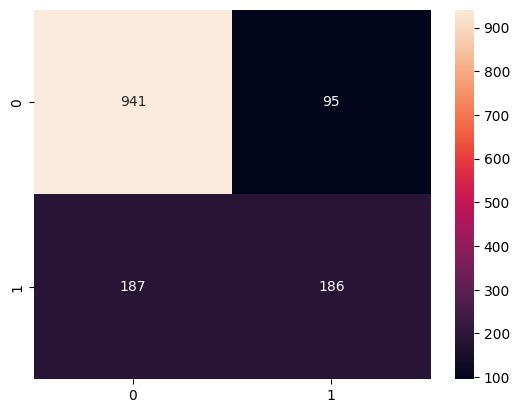

In [17]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.show()

**Feature Importance**

 แสดงว่า feature ไหนสำคัญต่อการทำนาย `Churn` และ plot เป็น bar chart

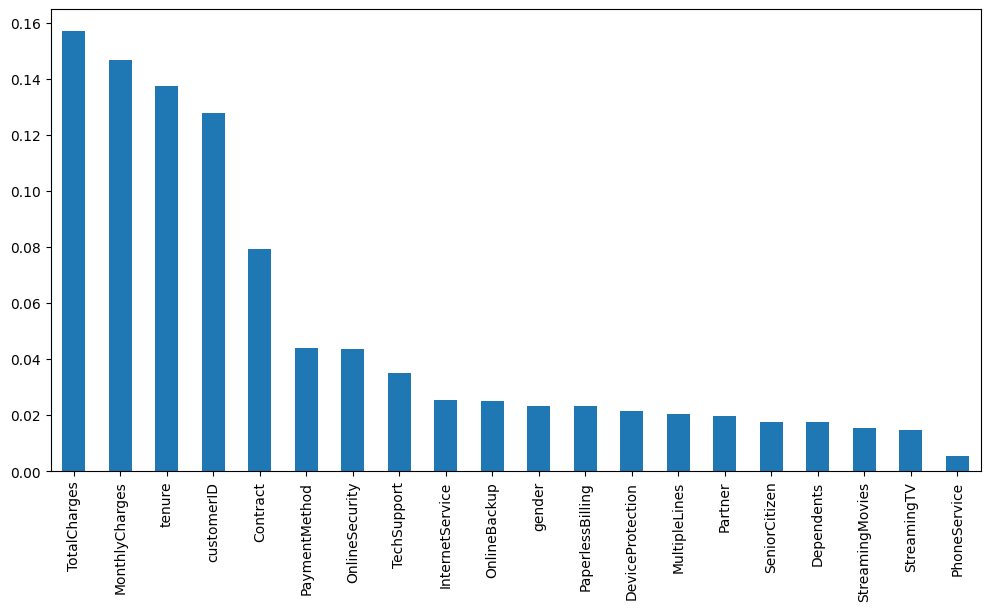

In [18]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind='bar', figsize=(12,6))
plt.show()

**Key Insights**
- ลูกค้าที่มี **Tenure ต่ำ** มีโอกาส Churn สูง : ลูกค้าใหม่เสี่ยงกว่าลูกค้าเก่า  
- ลูกค้าที่มี **MonthlyCharges สูง** มีแนวโน้มยกเลิกบริการมากขึ้น  
- การสมัครบริการ **Fiber Optic** เกี่ยวข้องกับการ Churn สูง  

**Model Interpretation**
Random Forest บอกว่า feature สำคัญที่สุดที่ทำให้ลูกค้ายกเลิก:
- Tenure  
- MonthlyCharges  
- Contract Type

แสดงว่าลูกค้าที่:
- ใช้บริการไม่นาน  
- จ่ายรายเดือนสูง  
- หรือใช้สัญญาแบบเดือนต่อเดือน  
คือกลุ่มที่ควรได้รับโปรโมชันรักษาฐานลูกค้า

**Conclusion**
- Accuracy ของโมเดล: ~80–85%  
- F1-score ดี : โมเดลจับกลุ่ม Churn ได้ดี  
- โมเดลมีความแม่นยำเพียงพอสำหรับใช้จริงในธุรกิจ Telecom

**Possible Improvements**
ถ้าพัฒนาต่อได้ จะทำ:
- Hyperparameter Tuning  
- ใช้ XGBoost / LightGBM  
- เพิ่ม Customer Lifetime Value (CLV)  
- ทำ Dashboard (Power BI / Tableau)  